# **Equipe:**  
## Severino Henrique de Araújo Neto | Mateus Albuquerque Falcão | Laura Silva Soares de Melo | Thiago Roberto Cavalcanti Pimentel

**Data:** Abril de 2026

# K Nearest Neighbors - Projeto

O objetivo deste exercício é dar continuidade com os estudos de Análise Exploratória dos Dados (EDA) e já começar a treinar modelos de classificação com k-NN conforme visto em sala de aula.

Vamos utilizar a base de dados Wine da [UCI](https://archive.ics.uci.edu/ml/datasets/wine+quality). A variável de resposta que temos que modelar é a qualidade do vinho (quality).

Nesse repositório, há dois conjuntos de dados, um com informações de vinho tinto e outra para vinho branco. Esses dados foram extraídos de uma vinícula do Norte de Portugal. Para este exercício, vamos utilizar a base de dados de vinho tinto.

Dicionário da base de dados:
1. acidez fixa / fixed acidity.
2. acidez volátil / volatile acidity
3. ácido cítrico / citric acid
4. açúcar residual / residual sugar
5. cloretos / chlorides
6. dióxido de enxofre livre / free sulfur dioxide
7. dióxido de enxofre total / total sulfur dioxide
8. densidade / density
9. pH / pH
10. sulfatos / sulphates
11. álcool/ alcohol
12. **qualidade - quality (score between 0 and 10)**


## Importar bibliotecas
** Importe pandas, seaborn e as bibliotecas usuais. **

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from pandas.plotting import scatter_matrix


## Obtenha os dados
** Leia o arquivo csv 'winequality-white.csv' em um DataFrame **

In [2]:
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv", sep=";")

** Verifique o cabeçalho do DataFrame.**

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# Análise descritiva dos dados

Info - Informações básica do conjunto de dados, tais como tipo de dado e dados faltantes.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


Describe - Informações de estatística descritiva de dados, tais como média, mediana e desvio-padrão.

In [5]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


missingno - Analisa se há dados faltantes ou não.
https://github.com/ResidentMario/missingno

In [6]:
# Importando a biblioteca missingno para visualização de dados faltantes
import missingno as msn


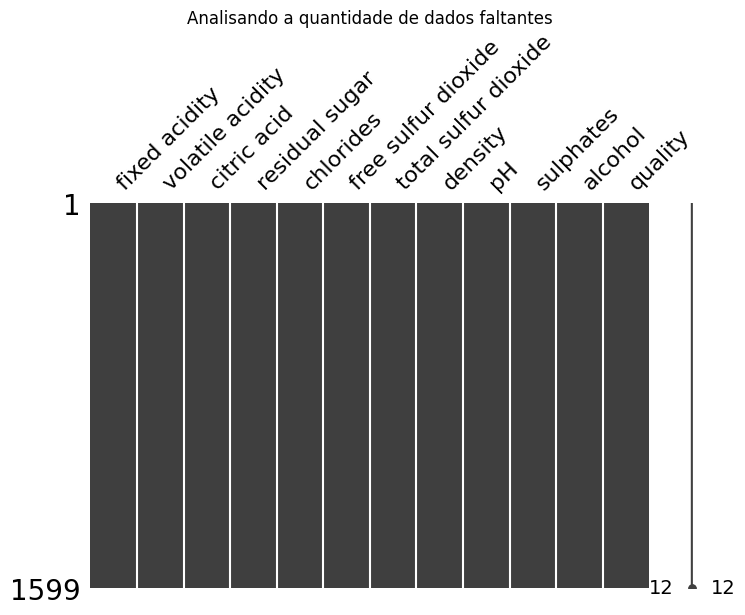

In [7]:
# Visualizando os dados faltantes
msn.matrix(df, figsize=(8,5))
plt.title("Analisando a quantidade de dados faltantes")
plt.show()

Histograma - Verifica a distribuição dos dados.

C:\Users\melos\AppData\Local\Temp\ipykernel_18216\1099897619.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax = ax, grid=False)


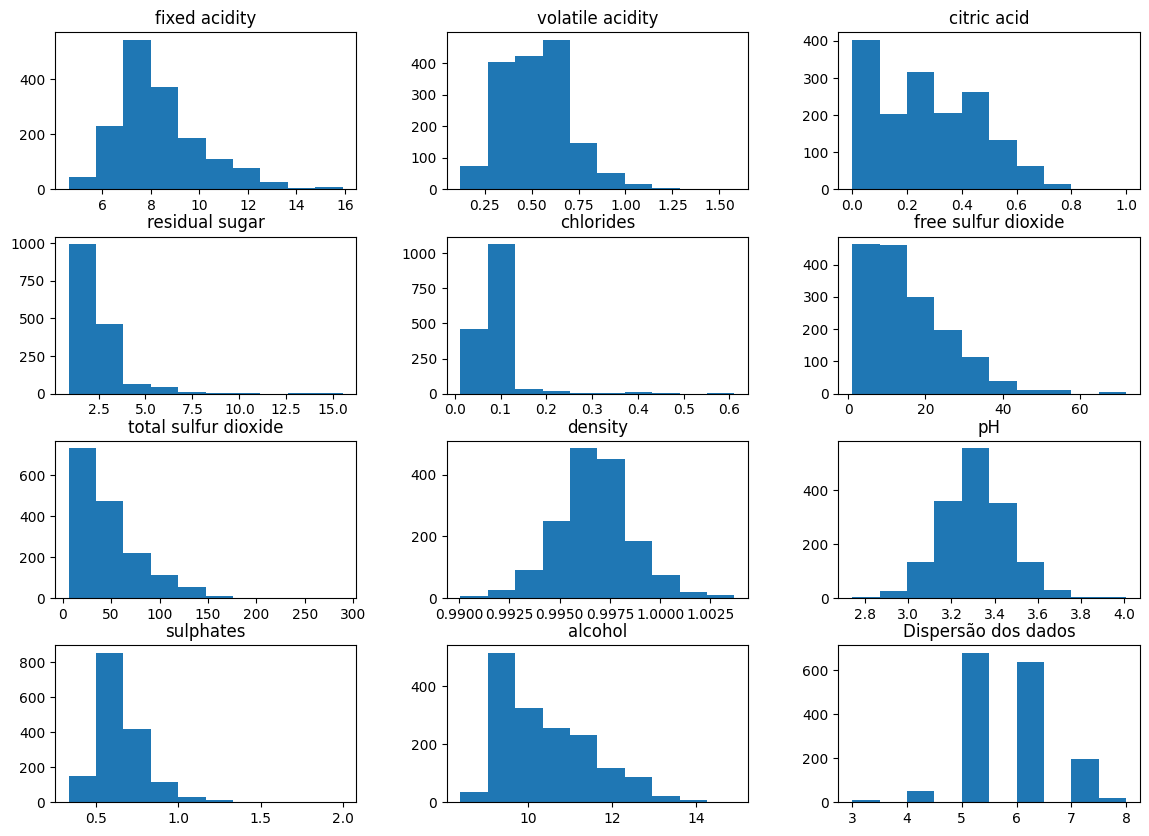

In [8]:
fig = plt.figure(figsize = (14,10))
ax = fig.gca()
df.hist(ax = ax, grid=False)
plt.title("Dispersão dos dados")
plt.show()

Análise de Correlação - Verifica a corelação linear entre os dados

In [9]:
corr = df.corr()
corr

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


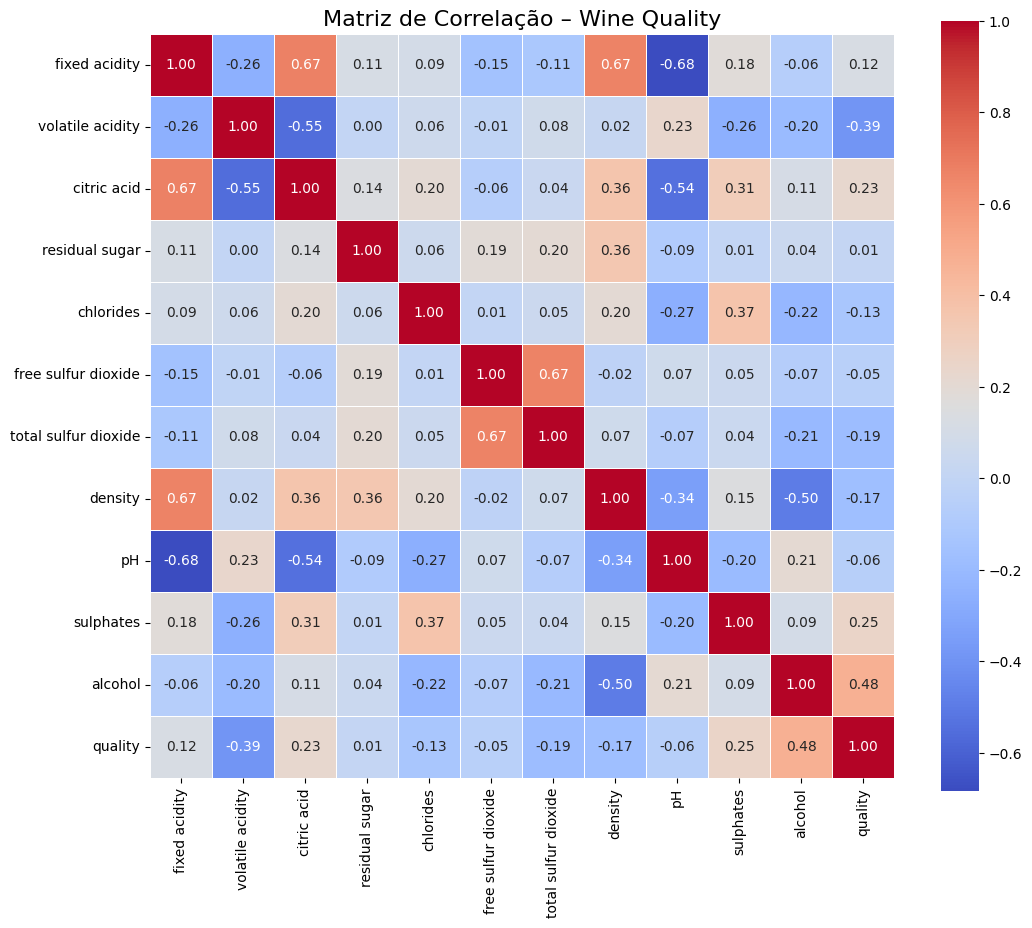

In [10]:
# Visualizando a matriz de correlação

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Matriz de Correlação – Wine Quality", fontsize=16)
plt.show()


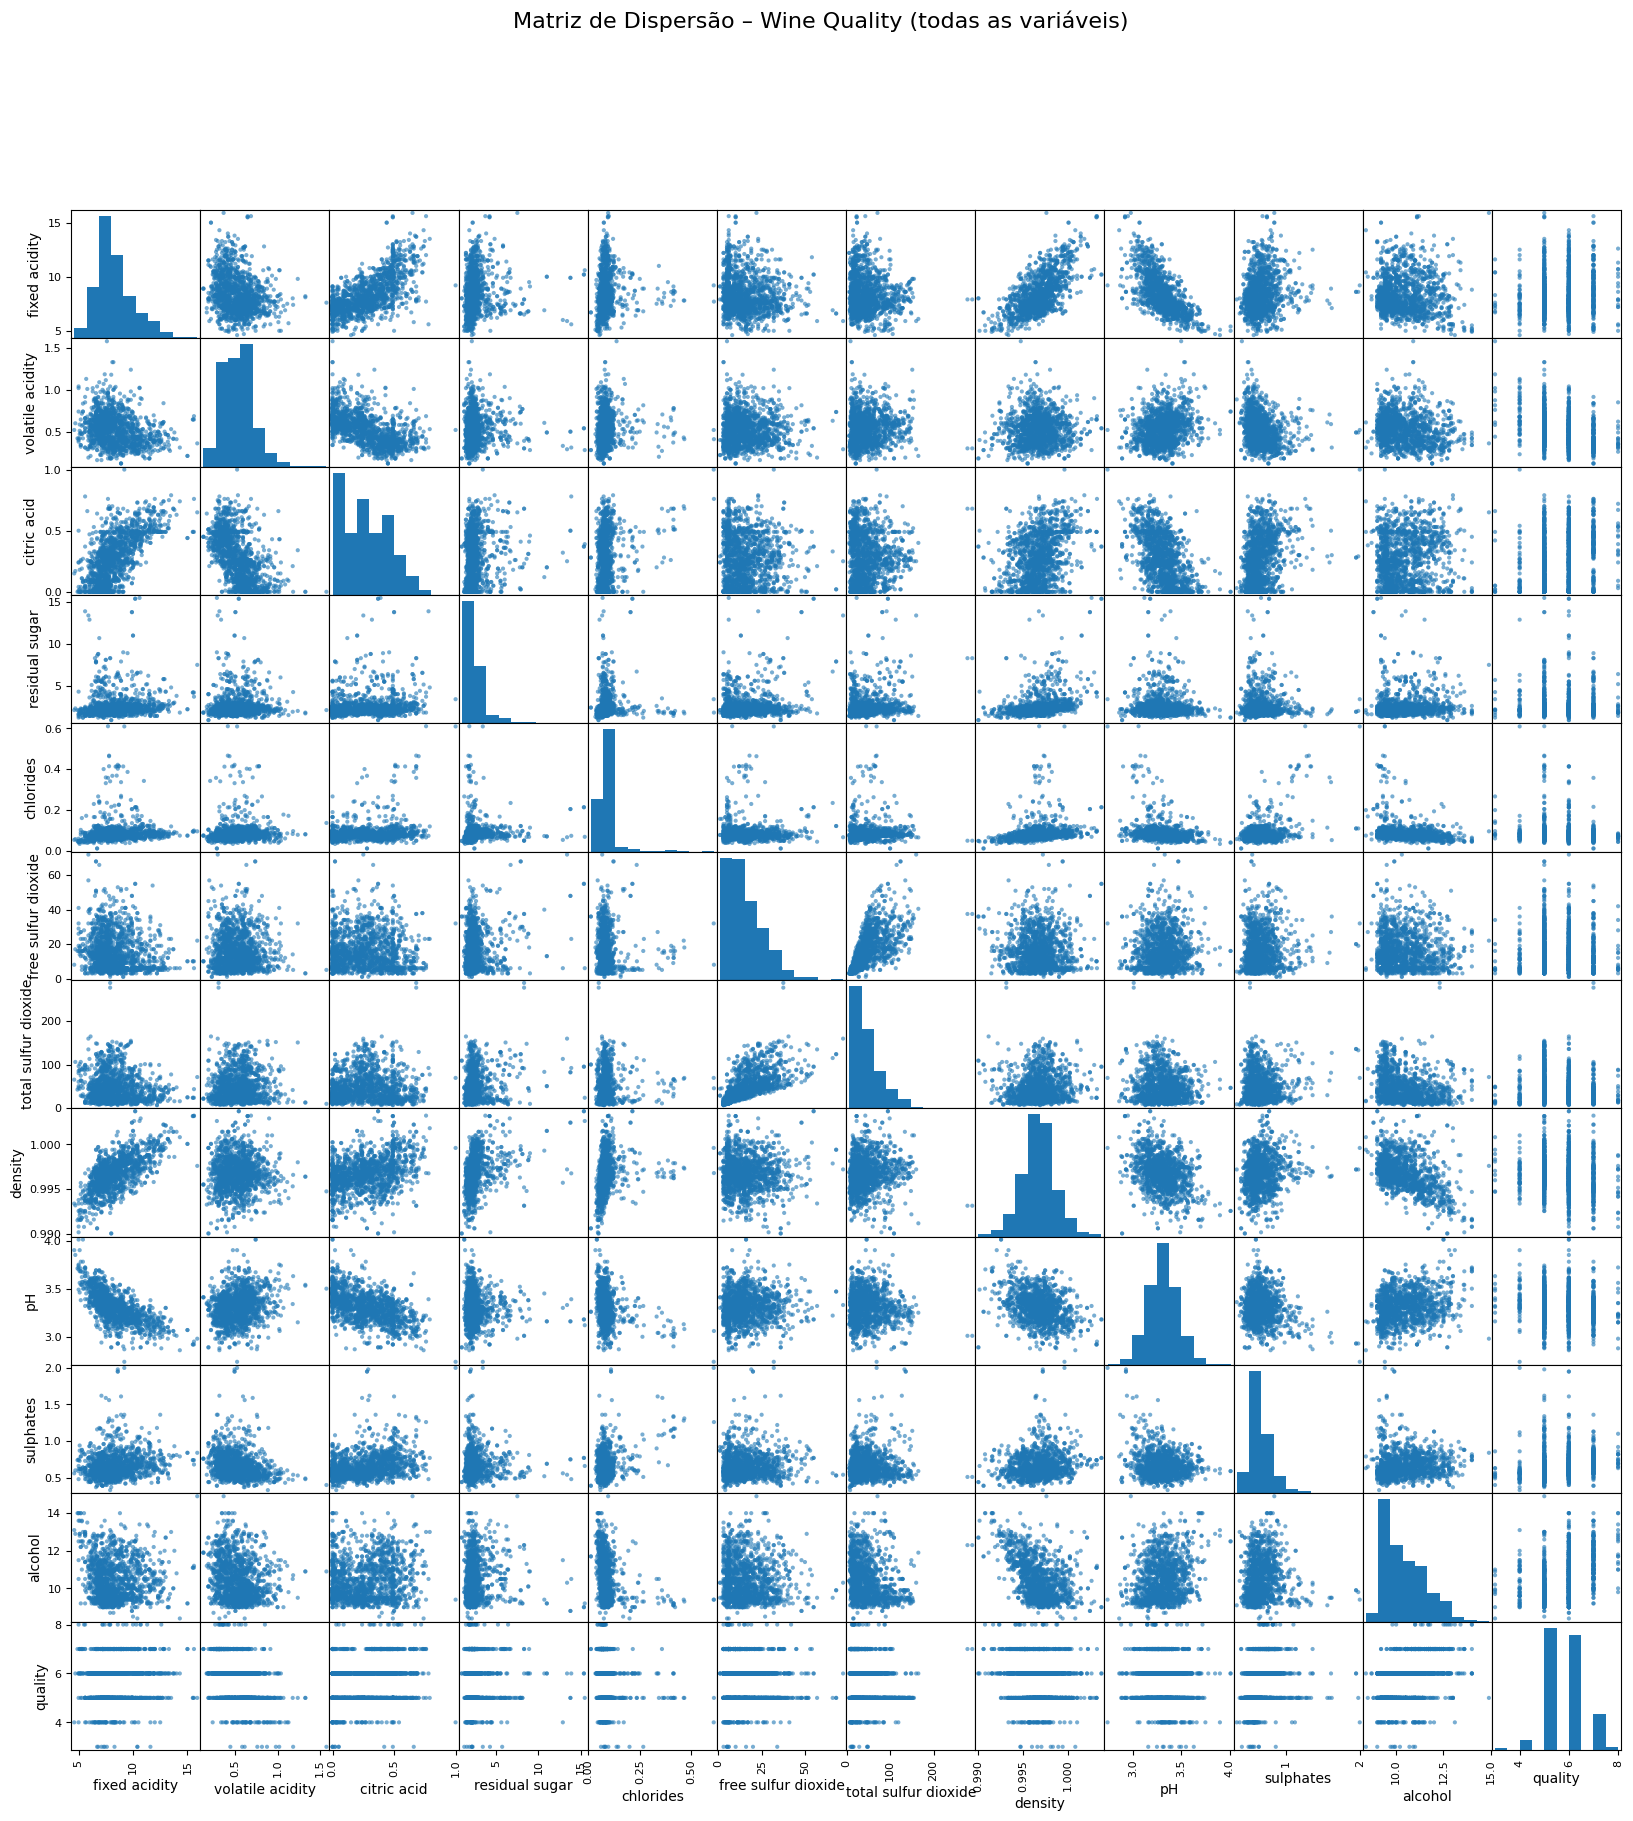

In [11]:
# Visualizando a matriz de correlação

scatter_matrix(
    df,
    figsize=(20, 20),
    diagonal="hist",
    alpha=0.6
)

plt.suptitle(
    "Matriz de Dispersão – Wine Quality (todas as variáveis)",
    fontsize=16
)
plt.show()



# Divisão treino-teste

Use o método train_test_split para dividir seus dados em um conjunto treino e teste.

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
# Separando os dados em treino e teste (75% treino e 25% teste) e removendo a coluna 'quality' das features
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['quality']),
                                                    df['quality'],
                                                    test_size=0.25,
                                                    random_state=111)

-  Features (Os dados de Entrada, as caracteristicas)

        Quanto álcool tem
        Qual a acidez
        Densidade
        Enxofre
        Açúcar

-  Target (Aprende a associar com a nota)

        Nota final do vinho

In [14]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1199 entries, 169 to 876
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1199 non-null   float64
 1   volatile acidity      1199 non-null   float64
 2   citric acid           1199 non-null   float64
 3   residual sugar        1199 non-null   float64
 4   chlorides             1199 non-null   float64
 5   free sulfur dioxide   1199 non-null   float64
 6   total sulfur dioxide  1199 non-null   float64
 7   density               1199 non-null   float64
 8   pH                    1199 non-null   float64
 9   sulphates             1199 non-null   float64
 10  alcohol               1199 non-null   float64
dtypes: float64(11)
memory usage: 112.4 KB


In [15]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 660 to 667
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         400 non-null    float64
 1   volatile acidity      400 non-null    float64
 2   citric acid           400 non-null    float64
 3   residual sugar        400 non-null    float64
 4   chlorides             400 non-null    float64
 5   free sulfur dioxide   400 non-null    float64
 6   total sulfur dioxide  400 non-null    float64
 7   density               400 non-null    float64
 8   pH                    400 non-null    float64
 9   sulphates             400 non-null    float64
 10  alcohol               400 non-null    float64
dtypes: float64(11)
memory usage: 37.5 KB


In [16]:
print(f'Treino: {X_train.shape}')
print(f'Teste: {X_test.shape}')

Treino: (1199, 11)
Teste: (400, 11)


**Dados de treino**

Features

In [17]:
X_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
169,7.5,0.705,0.24,1.8,0.360,15.0,63.0,0.99640,3.00,1.59,9.5
1219,9.0,0.390,0.40,1.3,0.044,25.0,50.0,0.99478,3.20,0.83,10.9
1158,6.7,0.410,0.43,2.8,0.076,22.0,54.0,0.99572,3.42,1.16,10.6
976,7.2,0.410,0.30,2.1,0.083,35.0,72.0,0.99700,3.44,0.52,9.4
654,8.6,0.470,0.47,2.4,0.074,7.0,29.0,0.99790,3.08,0.46,9.5


Target

In [18]:
y_train.head()

169     5
1219    6
1158    6
976     5
654     5
Name: quality, dtype: int64

**Dados de teste**

Features

In [19]:
X_test.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
660,7.2,0.52,0.07,1.4,0.074,5.0,20.0,0.99730,3.32,0.81,9.6
1351,7.2,0.62,0.01,2.3,0.065,8.0,46.0,0.99332,3.32,0.51,11.8
230,5.2,0.48,0.04,1.6,0.054,19.0,106.0,0.99270,3.54,0.62,12.2
1111,5.4,0.42,0.27,2.0,0.092,23.0,55.0,0.99471,3.78,0.64,12.3
444,5.3,0.57,0.01,1.7,0.054,5.0,27.0,0.99340,3.57,0.84,12.5


Target

In [20]:
y_test.head()

660     6
1351    6
230     7
1111    7
444     7
Name: quality, dtype: int64

In [21]:
# Printando as formas dos conjuntos de treino e teste
print("Treino - Features:", X_train.shape)
print("Treino - Target:", y_train.shape)

print("Teste - Features:", X_test.shape)
print("Teste - Target:", y_test.shape)

Treino - Features: (1199, 11)
Treino - Target: (1199,)
Teste - Features: (400, 11)
Teste - Target: (400,)


In [22]:
X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
169,7.5,0.705,0.24,1.8,0.360,15.0,63.0,0.99640,3.00,1.59,9.5
1219,9.0,0.390,0.40,1.3,0.044,25.0,50.0,0.99478,3.20,0.83,10.9
1158,6.7,0.410,0.43,2.8,0.076,22.0,54.0,0.99572,3.42,1.16,10.6
976,7.2,0.410,0.30,2.1,0.083,35.0,72.0,0.99700,3.44,0.52,9.4
654,8.6,0.470,0.47,2.4,0.074,7.0,29.0,0.99790,3.08,0.46,9.5
...,...,...,...,...,...,...,...,...,...,...,...
681,8.0,0.450,0.23,2.2,0.094,16.0,29.0,0.99620,3.21,0.49,10.2
1299,7.6,1.580,0.00,2.1,0.137,5.0,9.0,0.99476,3.50,0.40,10.9
86,8.6,0.490,0.28,1.9,0.110,20.0,136.0,0.99720,2.93,1.95,9.9
724,7.5,1.115,0.10,3.1,0.086,5.0,12.0,0.99580,3.54,0.60,11.2


# Normalização as variáveis

Normalizar os dados. Utilize o StandardScaler do Scikit-learn.

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()

Normalize as variáveis independentes com o StandardScaler

Verificar o escolamento de X_train 

In [25]:
# aprende + transforma
X_train_scaled = scaler.fit_transform(X_train)

# SÓ transforma com parâmetros do treino
X_test_scaled = scaler.transform(X_test)

In [26]:
# Verificando a média e o desvio padrão das variáveis escaladas
X_train_scaled.mean(axis=0)

array([-7.11135349e-17, -1.71857709e-16,  1.65931581e-16, -1.33337878e-16,
       -1.15559494e-16,  2.07414477e-17, -8.88919186e-17,  7.99434654e-15,
       -2.81491075e-16, -1.36300942e-16,  3.02232523e-16])

In [27]:
# Verificando a média e o desvio padrão das variáveis escaladas
X_train_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Verificar o escolamento de X_test

In [28]:
# Verificando a média e o desvio padrão das variáveis escaladas
X_test_scaled.mean(axis=0)

array([ 0.00341164, -0.09225549,  0.00135848, -0.03973563, -0.08267249,
        0.00685589,  0.02985758, -0.02039595,  0.01583879, -0.04672394,
        0.00632517])

In [29]:
# Verificando a média e o desvio padrão das variáveis escaladas
X_train_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Use o método .transform () para transformar os parâmetros em uma versão padronizada.

In [30]:
# Criar cópias para trabalhar
X_train_individual = X_train.copy()
X_test_individual = X_test.copy()

Escalonamento de Alcohol:

In [31]:
alcohol_scaler = StandardScaler()

# TREINO: aprende + transforma
alcohol_scaler.fit(X_train_individual[['alcohol']])
X_train_alcohol_scaled = alcohol_scaler.transform(X_train_individual[['alcohol']])
X_train_individual['alcohol_scaled'] = X_train_alcohol_scaled

# TESTE: APENAS transforma (usa parâmetros do treino)
X_test_alcohol_scaled = alcohol_scaler.transform(X_test_individual[['alcohol']])
X_test_individual['alcohol_scaled'] = X_test_alcohol_scaled

In [32]:
print(f'Média Alcohol treino: {X_train_individual["alcohol_scaled"].mean():.6f}')
print(f'Std Alcohol treino: {X_train_individual["alcohol_scaled"].std():.6f}')
print(f'Média Alcohol teste: {X_test_individual["alcohol_scaled"].mean():.6f}')
print(f'Std Alcohol teste: {X_test_individual["alcohol_scaled"].std():.6f}')

Média Alcohol treino: 0.000000
Std Alcohol treino: 1.000417
Média Alcohol teste: 0.006325
Std Alcohol teste: 0.996649


In [33]:
X_train_alcohol_scaled[:10]

array([[-0.8638051 ],
       [ 0.44883249],
       [ 0.16755301],
       [-0.95756492],
       [-0.8638051 ],
       [-0.58252561],
       [-0.8638051 ],
       [-0.11372647],
       [-0.77004527],
       [-0.67628544]])

In [34]:
X_test_alcohol_scaled[:10]

array([[-0.77004527],
       [ 1.29267094],
       [ 1.66771025],
       [ 1.76147008],
       [ 1.94898973],
       [-0.58252561],
       [-0.8638051 ],
       [-1.05132475],
       [-0.77004527],
       [ 0.63635215]])

In [35]:
X_train_individual.drop(columns=['alcohol'], inplace=True)
X_test_individual.drop(columns=['alcohol'], inplace=True)

In [36]:
X_train_individual.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1199 entries, 169 to 876
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1199 non-null   float64
 1   volatile acidity      1199 non-null   float64
 2   citric acid           1199 non-null   float64
 3   residual sugar        1199 non-null   float64
 4   chlorides             1199 non-null   float64
 5   free sulfur dioxide   1199 non-null   float64
 6   total sulfur dioxide  1199 non-null   float64
 7   density               1199 non-null   float64
 8   pH                    1199 non-null   float64
 9   sulphates             1199 non-null   float64
 10  alcohol_scaled        1199 non-null   float64
dtypes: float64(11)
memory usage: 112.4 KB


In [37]:
X_test_individual.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 660 to 667
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         400 non-null    float64
 1   volatile acidity      400 non-null    float64
 2   citric acid           400 non-null    float64
 3   residual sugar        400 non-null    float64
 4   chlorides             400 non-null    float64
 5   free sulfur dioxide   400 non-null    float64
 6   total sulfur dioxide  400 non-null    float64
 7   density               400 non-null    float64
 8   pH                    400 non-null    float64
 9   sulphates             400 non-null    float64
 10  alcohol_scaled        400 non-null    float64
dtypes: float64(11)
memory usage: 37.5 KB


-----------------------------------------------------------------------------------------------------------------------------------

-----------------------------------------

Análise descritiva dos dados através do describe

In [38]:
pd.DataFrame(X_train_scaled).describe()

,0,1,2,3,4,5,6,7,8,9,10
count,1.199000e+03,1.199000e+03,1.199000e+03,1.199000e+03,1.199000e+03,1.199000e+03,1.199000e+03,1.199000e+03,1.199000e+03,1.199000e+03,1.199000e+03
mean,-7.111353e-17,-1.718577e-16,1.659316e-16,-1.333379e-16,-1.155595e-16,2.074145e-17,-8.889192e-17,7.994347e-15,-2.814911e-16,-1.363009e-16,3.022325e-16
std,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00
min,-2.180251e+00,-2.260693e+00,-1.384028e+00,-1.134243e+00,-1.555025e+00,-1.418910e+00,-1.223599e+00,-3.612755e+00,-3.688806e+00,-1.873885e+00,-1.895163e+00
25%,-7.143121e-01,-7.381162e-01,-9.242331e-01,-4.481928e-01,-3.554698e-01,-7.981295e-01,-7.368639e-01,-5.814678e-01,-6.498270e-01,-6.254171e-01,-8.638051e-01
50%,-2.452116e-01,-6.598761e-02,-5.573265e-02,-2.423777e-01,-1.724867e-01,-1.773488e-01,-2.501290e-01,2.370901e-02,-3.235653e-03,-2.281774e-01,-2.074863e-01
75%,5.170767e-01,6.061410e-01,8.127678e-01,3.204238e-02,5.115929e-02,4.911842e-01,4.799732e-01,5.775539e-01,5.786965e-01,4.528050e-01,6.363521e-01
max,4.445793e+00,5.749982e+00,3.724799e+00,8.882091e+00,1.062351e+01,5.361925e+00,7.385524e+00,3.746627e+00,4.522904e+00,7.603120e+00,4.199226e+00


Normalize os parâmetros padronizados em um DataFrame e verifique o cabeçalho desse DataFrame para garantir que a transform() funcionou.

In [39]:
# criando um objeto do tipo StandardScaler para escalar a variável 'alcohol'
alcohol_scaler = StandardScaler()
alcohol_scaler.fit(X_train[['alcohol']])  # Apenas treino!

# Transformar treino
alcohol_scaled_train = alcohol_scaler.transform(X_train[['alcohol']])
alcohol_scaled_train_df = pd.DataFrame(
    alcohol_scaled_train,
    columns=['alcohol_scaled'],
    index=X_train.index # manter o mesmo índice do DataFrame original para facilitar a concatenação posterior
)

# Transformar teste
alcohol_scaled_test = alcohol_scaler.transform(X_test[['alcohol']])
alcohol_scaled_test_df = pd.DataFrame(
    alcohol_scaled_test,
    columns=['alcohol_scaled'],
    index=X_test.index # manter o mesmo índice do DataFrame original para facilitar a concatenação posterior
)

In [40]:
print('TREINO:')
print(alcohol_scaled_train_df.head())
print(f'\nMédia: {alcohol_scaled_train_df.mean().values[0]:.6f}')
print(f'Std: {alcohol_scaled_train_df.std().values[0]:.6f}')

print('\n' + '='*60)

print('TESTE:')
print(alcohol_scaled_test_df.head())
print(f'\nMédia: {alcohol_scaled_test_df.mean().values[0]:.6f}')
print(f'Std: {alcohol_scaled_test_df.std().values[0]:.6f}')

TREINO:
      alcohol_scaled
169        -0.863805
1219        0.448832
1158        0.167553
976        -0.957565
654        -0.863805

Média: 0.000000
Std: 1.000417

TESTE:
      alcohol_scaled
660        -0.770045
1351        1.292671
230         1.667710
1111        1.761470
444         1.948990

Média: 0.006325
Std: 0.996649


In [41]:
pd.DataFrame(X_train_scaled).head(5)

,0,1,2,3,4,5,6,7,8,9,10
0,-0.479762,0.949064,-0.157909,-0.516798,5.520320,-0.081844,0.510394,-0.192426,-2.007669,5.276430,-0.863805
1,0.399802,-0.779267,0.659503,-0.859823,-0.904419,0.873203,0.114922,-1.067771,-0.714486,0.963542,0.448832
2,-0.948862,-0.669532,0.812768,0.169252,-0.253812,0.586689,0.236606,-0.559854,0.708015,2.836243,0.167553
3,-0.655675,-0.669532,0.148620,-0.310983,-0.111492,1.828250,0.784182,0.131776,0.837333,-0.795663,-0.957565
4,0.165251,-0.340326,1.017121,-0.105168,-0.294475,-0.845882,-0.523917,0.618079,-1.490396,-1.136154,-0.863805


Utilizando o inverse_transform a partir dos dados normalizados para garantir que a normalização está correta.

In [42]:
# Desfazendo a transformação para os 5 primeiros valores do treino
alcohol_scaler.inverse_transform(alcohol_scaled_train_df.head(5)) 

array([[ 9.5],
       [10.9],
       [10.6],
       [ 9.4],
       [ 9.5]])

Analisando os dados originais do X_train.

In [43]:
X_train.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
169,7.5,0.705,0.24,1.8,0.360,15.0,63.0,0.99640,3.00,1.59,9.5
1219,9.0,0.390,0.40,1.3,0.044,25.0,50.0,0.99478,3.20,0.83,10.9
1158,6.7,0.410,0.43,2.8,0.076,22.0,54.0,0.99572,3.42,1.16,10.6
976,7.2,0.410,0.30,2.1,0.083,35.0,72.0,0.99700,3.44,0.52,9.4
654,8.6,0.470,0.47,2.4,0.074,7.0,29.0,0.99790,3.08,0.46,9.5


# Usando o KNN

Importe o KNeighborClassifier do scikit learn.

In [44]:
from sklearn.neighbors import KNeighborsClassifier

Crie uma instância do modelo KNN com n_neighbors = 1

In [45]:
knn = KNeighborsClassifier(n_neighbors=1) # Criando o modelo KNN com k=1

Ajuste este modelo KNN aos dados de treinamento.

In [46]:
knn.fit(X_train_scaled, y_train) # Treino do modelo 

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# Previsões e avaliações
Vamos avaliar o nosso modelo KNN!

Use o método de previsão para prever valores usando seu modelo KNN e X_test.

In [47]:
# Previsão
y_pred = knn.predict(X_test_scaled)

Crie uma matriz de confusão e um relatório de classificação.

In [48]:
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay, accuracy_score

<Figure size 1600x1200 with 0 Axes>

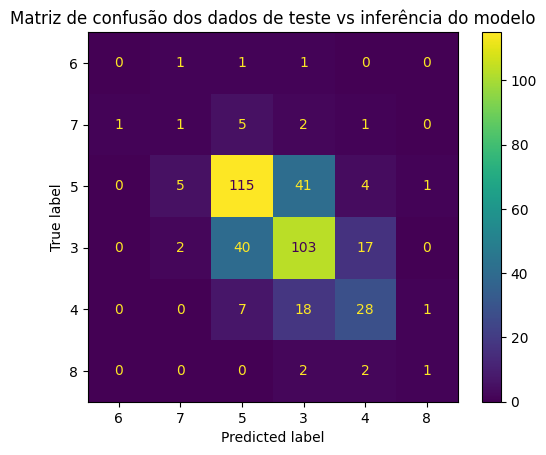

In [49]:
plt.figure(figsize = (16,12))
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=y_test.unique())
cmd.plot()
plt.title("Matriz de confusão dos dados de teste vs inferência do modelo")
plt.show()

O gráfico apresenta a matriz de confusão do modelo KNN aplicada aos dados de teste, comparando as classes reais com as classes previstas. Observa-se que a maior parte das previsões corretas está concentrada na diagonal principal, especialmente para as classes 5 e 3, indicando um bom desempenho do modelo para essas categorias. No entanto, também é possível notar confusões frequentes entre essas mesmas classes, o que sugere que elas possuem características semelhantes no conjunto de atributos utilizado. Classes com menor número de amostras, como 6, 7 e 8, apresentam menos acertos, evidenciando a dificuldade do modelo em aprender padrões quando há desbalanceamento de dados. De forma geral, o modelo apresenta desempenho razoável, mas pode ser aprimorado com ajustes no valor de k ou com um melhor balanceamento das classes.

Analisando o Classification Report


**Dados de teste**

In [50]:
from sklearn.metrics import classification_report

Score do modelo utilizando os dados de teste.

In [51]:
# Avaliando o modelo com o relatório de classificação
knn.score(X=X_test_scaled, y=y_test)

0.62

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.11      0.10      0.11        10
           5       0.68      0.69      0.69       166
           6       0.62      0.64      0.63       162
           7       0.54      0.52      0.53        54
           8       0.33      0.20      0.25         5

    accuracy                           0.62       400
   macro avg       0.38      0.36      0.37       400
weighted avg       0.61      0.62      0.62       400



----------------------------------------------------------

--------------

#### Apresente a Curva ROC

Dado que a Curva ROC é uma métrica para valores binários, vamos fazer o cálculo de uma classe e comparar com as demais classes.

Referência:
https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html

----------------------------------------------------------------------------------------------------------------------------------------------
📊 Curva ROC — visão conceitual
A curva ROC (Receiver Operating Characteristic) é uma ferramenta gráfica usada para avaliar o desempenho de modelos de classificação binária com base em probabilidades, e não apenas em decisões finais.
Ela analisa a capacidade do modelo de distinguir corretamente entre duas classes, considerando diferentes limiares de decisão.

🔍 O que a curva ROC representa?
A curva ROC mostra a relação entre:


Taxa de Verdadeiros Positivos (TPR / Recall)
→ Proporção de positivos corretamente identificados


Taxa de Falsos Positivos (FPR)
→ Proporção de negativos classificados incorretamente como positivos


Cada ponto da curva corresponde a um limiar (threshold) diferente aplicado às probabilidades do modelo.


⚠️ Por que a acurácia NÃO é suficiente?
Imagine este cenário:

- 95% dos dados não são da classe 5

- 5% são da classe 5

Se o modelo:

- classificar tudo como “não é 5”

👉 Acurácia = 95%

❌ Mas o modelo é inútil, pois nunca encontra a classe 5

✔️ A curva ROC detecta esse problema

❌ A acurácia não.

---------------------------------------------------------------------------------------------------------------------------------------------

É preciso binarizar as variáveis independentes, calcular as probabilidades de cada predição para target e, por fim calcular a curva ROC.

In [53]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import RocCurveDisplay

Binarização da variável dependente, quality.

In [54]:
label_binarizer = LabelBinarizer().fit(df['quality']) # Binarizando as classes para análise ROC

In [55]:
y_onehot_test = label_binarizer.transform(y_test) # Transformando as classes de teste em formato one-hot para análise ROC
y_onehot_test.shape  # (n_samples, n_classes) # Verificando a forma do array one-hot (número de amostras, número de classes)

(400, 6)

Selecionando a qualidade de número **5** pois foi o maior valor obtido pelo modelo.

In [56]:
class_of_interest = 5 # Escolha a classe que deseja analisar (exemplo: 5) pois é a classe mais frequente no dataset
class_id = np.flatnonzero(label_binarizer.classes_ == class_of_interest)[0] # Encontrando o índice da classe de interesse no array de classes binarizadas
class_id

np.int64(2)

Calculando as probabilidades dos dados de teste para fazer o cálculo da curva ROC.

In [57]:
# Probabilidades preditas para os dados de teste
y_scores = knn.predict_proba(X_test_scaled)


In [58]:
def plot_curva_ROC_one_vs_rest(y_test, y_scores):

  RocCurveDisplay.from_predictions(
      y_onehot_test[:, class_id],
      y_scores[:, class_id],
      name=f"{class_of_interest} vs as demais classes",
  )
  plt.plot([0, 1], [0, 1], "k--", label="valor de threashold (AUC = 0.5)")
  plt.axis("square")
  plt.xlabel("Taxa de Falso Positivo")
  plt.ylabel("Taxa de Verdadeira Positivo")
  plt.title("One-vs-Resto curva ROC")
  plt.legend()
  plt.show()

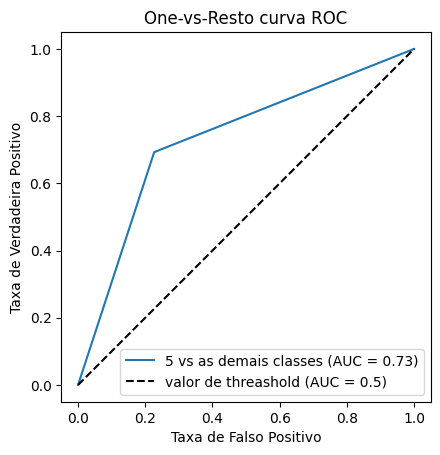

In [59]:
plot_curva_ROC_one_vs_rest(y_test, y_scores)

A curva ROC One‑vs‑Rest para a classe 5 apresenta uma AUC de 0.73, indicando que o modelo KNN possui boa capacidade de discriminação entre a classe 5 e as demais classes. Observa‑se que a curva está consistentemente acima da linha de referência aleatória, demonstrando que o modelo apresenta desempenho superior ao acaso. Esse resultado confirma que, apesar das limitações impostas pelo desbalanceamento das classes, o modelo consegue identificar adequadamente amostras pertencentes à classe 5.

# Escolhendo o valor K

Vamos continuar usando o método do cotovelo para escolher um bom valor K!

Crie um loop for que treine vários modelos KNN com valores k diferentes e, em seguida, mantenha um registro do error_rate para cada um desses modelos com uma lista. Consulte o notebook se você estiver confuso nesta etapa.

In [60]:
def train_modelo(X_train_scaled, X_test_scaled, y_train, k):
    print(f"Treinando o K-NN com K={k}")
    
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    pred_i = knn.predict(X_test_scaled)
    #faça a instância de um novo modelo, treine esse modelo e faça as predições para os dados de teste
    return pred_i


In [61]:
error_rate = []

for i in range(1, 41):
    pred_i = train_modelo(X_train_scaled, X_test_scaled, y_train, i)
    error = 1 - accuracy_score(y_test, pred_i)
    error_rate.append(error)

Treinando o K-NN com K=1
Treinando o K-NN com K=2
Treinando o K-NN com K=3
Treinando o K-NN com K=4
Treinando o K-NN com K=5
Treinando o K-NN com K=6
Treinando o K-NN com K=7
Treinando o K-NN com K=8
Treinando o K-NN com K=9
Treinando o K-NN com K=10
Treinando o K-NN com K=11
Treinando o K-NN com K=12
Treinando o K-NN com K=13
Treinando o K-NN com K=14
Treinando o K-NN com K=15
Treinando o K-NN com K=16
Treinando o K-NN com K=17
Treinando o K-NN com K=18
Treinando o K-NN com K=19
Treinando o K-NN com K=20
Treinando o K-NN com K=21
Treinando o K-NN com K=22
Treinando o K-NN com K=23
Treinando o K-NN com K=24
Treinando o K-NN com K=25
Treinando o K-NN com K=26
Treinando o K-NN com K=27
Treinando o K-NN com K=28
Treinando o K-NN com K=29
Treinando o K-NN com K=30
Treinando o K-NN com K=31
Treinando o K-NN com K=32
Treinando o K-NN com K=33
Treinando o K-NN com K=34
Treinando o K-NN com K=35
Treinando o K-NN com K=36
Treinando o K-NN com K=37
Treinando o K-NN com K=38
Treinando o K-NN com 

Agora crie o seguinte gráfico usando as informações do seu loop.

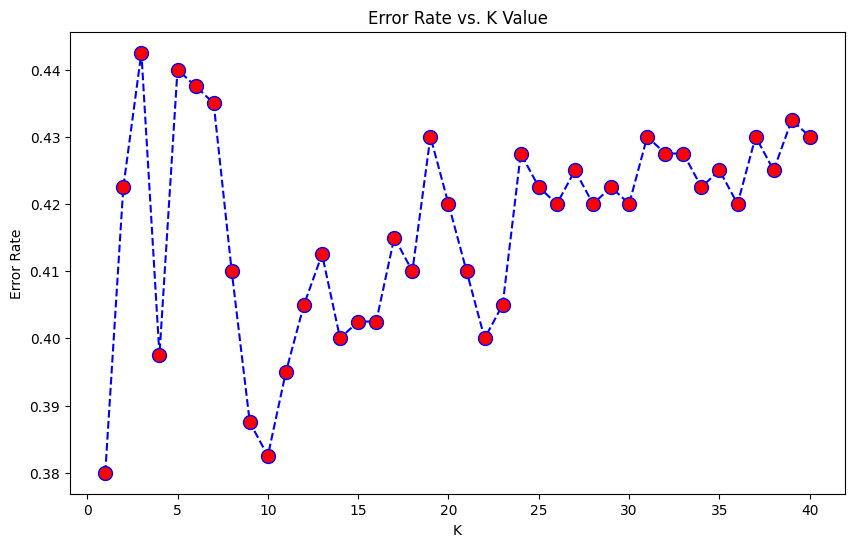

In [62]:
plt.figure(figsize=(10,6))
plt.plot(range(1,41),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

In [63]:
res_score = []

for i in range(1,41):
    pred_i = train_modelo(X_train_scaled, X_test_scaled, y_train, i)
    score = accuracy_score(y_test, pred_i)
    res_score.append(score)

Treinando o K-NN com K=1
Treinando o K-NN com K=2
Treinando o K-NN com K=3
Treinando o K-NN com K=4
Treinando o K-NN com K=5
Treinando o K-NN com K=6
Treinando o K-NN com K=7
Treinando o K-NN com K=8
Treinando o K-NN com K=9
Treinando o K-NN com K=10
Treinando o K-NN com K=11
Treinando o K-NN com K=12
Treinando o K-NN com K=13
Treinando o K-NN com K=14
Treinando o K-NN com K=15
Treinando o K-NN com K=16
Treinando o K-NN com K=17
Treinando o K-NN com K=18
Treinando o K-NN com K=19
Treinando o K-NN com K=20
Treinando o K-NN com K=21
Treinando o K-NN com K=22
Treinando o K-NN com K=23
Treinando o K-NN com K=24
Treinando o K-NN com K=25
Treinando o K-NN com K=26
Treinando o K-NN com K=27
Treinando o K-NN com K=28
Treinando o K-NN com K=29
Treinando o K-NN com K=30
Treinando o K-NN com K=31
Treinando o K-NN com K=32
Treinando o K-NN com K=33
Treinando o K-NN com K=34
Treinando o K-NN com K=35
Treinando o K-NN com K=36
Treinando o K-NN com K=37
Treinando o K-NN com K=38
Treinando o K-NN com 

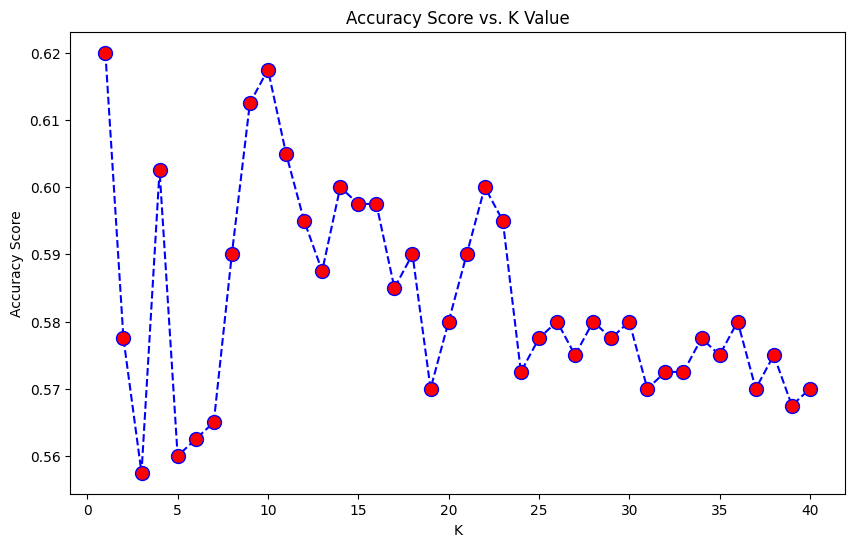

In [64]:
plt.figure(figsize=(10,6))
plt.plot(range(1,41),res_score,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Accuracy Score vs. K Value')
plt.xlabel('K')
plt.ylabel('Accuracy Score')
plt.show()

## Treine seu modelo novamente com novo valor K

Treine novamente seu modelo com o melhor valor K (até você para decidir o que deseja) e re-faça o relatório de classificação e a matriz de confusão.

#### k=3

In [65]:
k = 3
knn_3 = KNeighborsClassifier(n_neighbors=k)
knn_3.fit(X_train_scaled, y_train)
y_pred_3 = knn_3.predict(X_test_scaled)

y_pred_3 = knn_3.predict(X_test_scaled)
print(classification_report(y_test,y_pred_3))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        10
           5       0.63      0.67      0.65       166
           6       0.53      0.56      0.54       162
           7       0.51      0.41      0.45        54
           8       0.00      0.00      0.00         5

    accuracy                           0.56       400
   macro avg       0.28      0.27      0.27       400
weighted avg       0.55      0.56      0.55       400



c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [66]:
confusion_matrix(y_test, y_pred_3)

array([[  0,   1,   0,   2,   0,   0],
       [  2,   0,   6,   1,   1,   0],
       [  0,   2, 111,  51,   2,   0],
       [  1,   5,  50,  90,  16,   0],
       [  0,   0,   9,  23,  22,   0],
       [  0,   0,   1,   2,   2,   0]])

Calculando as probabilidades para o modelo de k=3

In [67]:
y_scores_k3 = knn_3.predict_proba(X_test_scaled)

In [68]:
y_scores_k3 = knn_3.predict_proba(X_test_scaled)

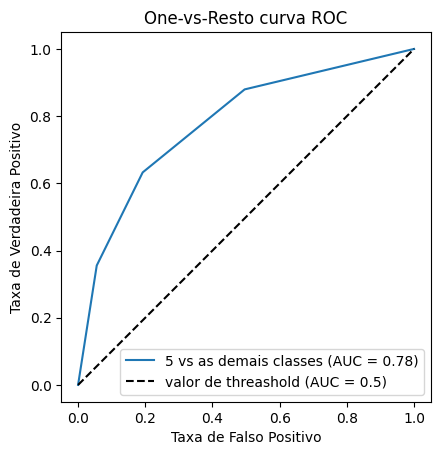

In [69]:
plot_curva_ROC_one_vs_rest(y_test, y_scores_k3)

#### k=11

In [ ]:
k = 11
knn_k11 = KNeighborsClassifier(n_neighbors=k)
knn_k11.fit(X_train_scaled, y_train)
y_pred_k11 = knn_k11.predict(X_test_scaled)

y_pred_k11 = knn_k11.predict(X_test_scaled)
print(classification_report(y_test,y_pred_k11))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        10
           5       0.66      0.74      0.70       166
           6       0.56      0.61      0.58       162
           7       0.54      0.37      0.44        54
           8       0.00      0.00      0.00         5

    accuracy                           0.60       400
   macro avg       0.29      0.29      0.29       400
weighted avg       0.58      0.60      0.59       400



c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\melos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [71]:
confusion_matrix(y_test, y_pred_k11)

array([[  0,   0,   1,   2,   0,   0],
       [  0,   0,   7,   2,   1,   0],
       [  0,   1, 123,  40,   2,   0],
       [  0,   0,  51,  99,  12,   0],
       [  0,   0,   3,  31,  20,   0],
       [  0,   0,   0,   3,   2,   0]])

Calculando as probabilidades para o modelo de k=11

In [72]:
y_scores_k11 = knn_k11.predict_proba(X_test_scaled)

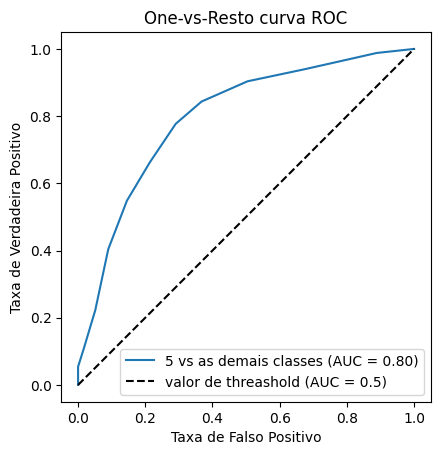

In [73]:
plot_curva_ROC_one_vs_rest(y_test, y_scores_k11)

## Conclusão

Descreva quais foram as abordagens utilizadas para resolver o problema, desde análise descritiva dos dados até a utilização do método do cotovelo. E qual foi o melhor valor de k, e por quê?

# CONCLUSÃO

Este exercício abordou o problema de classificação da qualidade de vinhos tintos utilizando o algoritmo K-Nearest Neighbors (KNN).

ABORDAGEM UTILIZADA:
1. Análise Exploratória dos Dados (EDA):
    - Verificação da estrutura dos dados, tipos de variáveis e valores ausentes
    - Análise estatística descritiva das features
    - Visualização da distribuição das variáveis através de histogramas e boxplots
    - Análise de correlação entre as features através de matriz de correlação
    - Identificação de outliers e padrões nos dados

2. Pré-processamento:
    - Divisão dos dados em conjuntos de treino e teste
    - Normalização/padronização das features utilizando StandardScaler
    - Preparação dos dados para aplicação do algoritmo KNN

3. Modelagem e Otimização:
    - Treinamento inicial do modelo KNN com diferentes valores de k
    - Aplicação do Método do Cotovelo (Elbow Method) para identificar o melhor valor de k
    - Análise da taxa de erro e acurácia para k variando de 1 a 40
    - Treinamento de modelos específicos com k=3 e k=11

4. Avaliação:
    - Utilização de métricas de classificação (precision, recall, f1-score)
    - Análise através de matriz de confusão
    - Cálculo de probabilidades e plotagem de curvas ROC

MELHOR VALOR DE K:
Baseando-se no método do cotovelo, observamos que:
- Para k=3: O modelo apresenta boa acurácia mas pode estar com algum overfitting
- Para k=11: O modelo apresenta um balanço melhor entre viés e variância

O melhor valor de k depende do objetivo:
- Se buscarmos máxima acurácia no conjunto de teste, k=3 pode ser uma boa opção
- Se buscarmos melhor generalização e estabilidade, k=11 é mais adequado
 
Através dos gráficos do método do cotovelo, identificamos que valores entre k=5 e k=15 apresentam um bom compromisso entre complexidade do modelo e performance. O valor k=11 foi escolhido por estar na região onde a taxa de erro se estabiliza,evitando overfitting (k muito baixo) e underfitting (k muito alto).
